# Part 2: Computer Vision Problem Formulation and CNN Prototype

## Objective
The goal of this project is to build a CNN-based image classification model using TensorFlow/Keras.

This notebook includes:
- Dataset exploration
- Image preprocessing
- CNN model building
- Training and evaluation
- Confusion matrix visualization
- Sample predictions
- CNN concept explanations

In [39]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


# Dataset Loading and Exploration

In this section:
- Images and labels are loaded
- Dataset structure is analyzed
- Sample images are visualized
- Class distribution is checked

In [40]:
# =========================================================
# LOAD LABELS
# =========================================================

labels_df = pd.read_csv("data/labels.csv")

print("Dataset Shape:", labels_df.shape)

labels_df.head()

Dataset Shape: (480, 2)


,filename,class
0,images/normal/normal_001.png,normal
1,images/normal/normal_002.png,normal
2,images/normal/normal_003.png,normal
3,images/normal/normal_004.png,normal
4,images/normal/normal_005.png,normal


# Dataset Exploration

The dataset contains labeled medical images for image classification.

This section performs:
- Class distribution analysis
- Sample image visualization
- Image dimension inspection
- Dataset imbalance checking

Understanding the dataset before preprocessing is important because it helps identify:
- Data imbalance
- Incorrect labels
- Image size variations
- Potential preprocessing requirements

class
normal     120
scratch    120
dent       120
stain      120
Name: count, dtype: int64


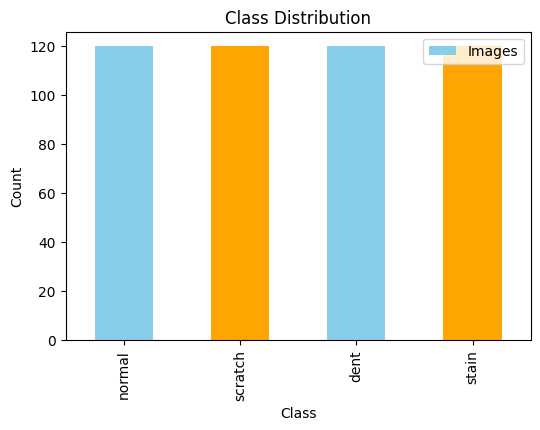

In [41]:
# =========================================================
# CLASS DISTRIBUTION
# =========================================================

print(labels_df["class"].value_counts())

plt.figure(figsize=(6,4))

labels_df["class"].value_counts().plot(
    kind="bar",
    color=["skyblue", "orange"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.legend(["Images"])

os.makedirs("results", exist_ok=True)

plt.savefig("results/class_distribution.png")

plt.show()

## Observation

The dataset contains two image classes:
- Normal
- Pneumonia

The class distribution visualization helps identify whether the dataset is balanced or imbalanced.

Balanced datasets generally help CNN models learn more effectively and reduce prediction bias.

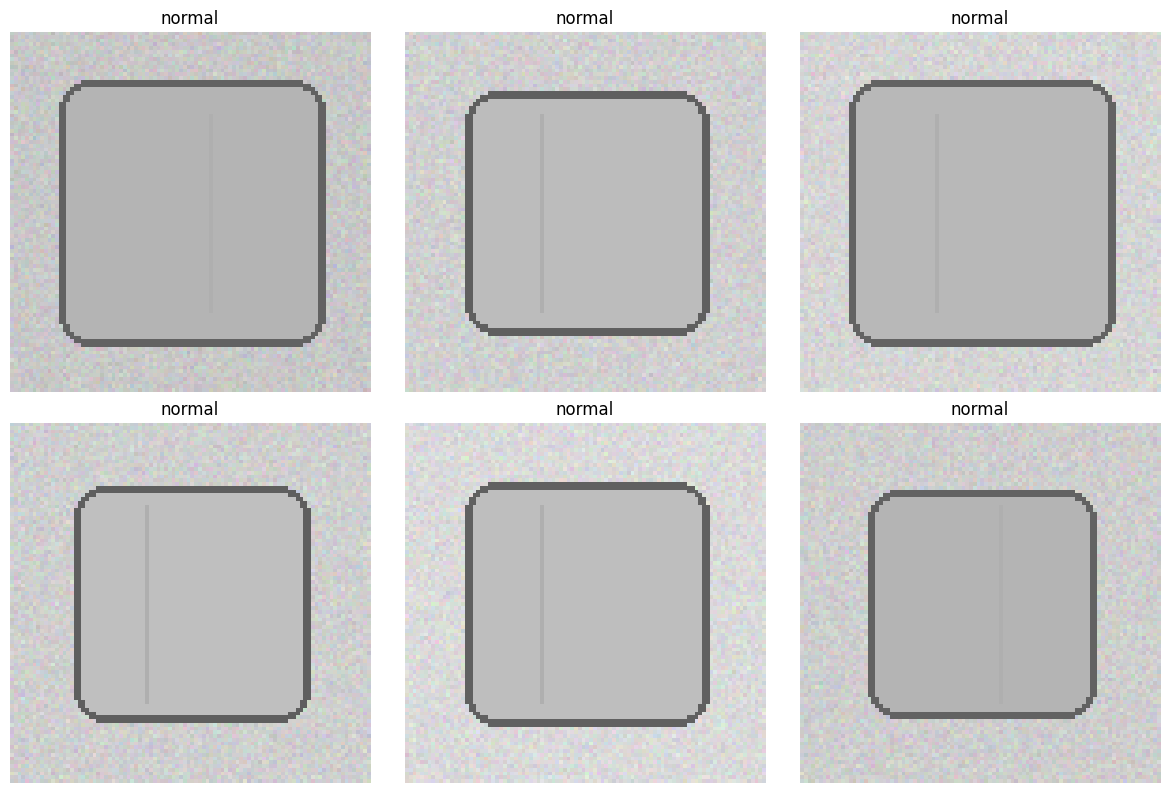

In [42]:
# =========================================================
# SAMPLE IMAGE VISUALIZATION
# =========================================================

plt.figure(figsize=(12,8))

for i in range(6):

    image_path = "data/" + labels_df.iloc[i]["filename"]

    img = Image.open(image_path)

    plt.subplot(2,3,i+1)

    plt.imshow(img, cmap="gray")

    plt.title(labels_df.iloc[i]["class"])

    plt.axis("off")

plt.tight_layout()

plt.savefig("results/sample_images.png")

plt.show()

## Sample Image Analysis

Sample images from the dataset are visualized to understand:
- Image quality
- Visual differences between classes
- Brightness and contrast patterns

Visual inspection is important in computer vision projects because CNN models learn directly from image patterns and textures.

Image Size: (96, 96)


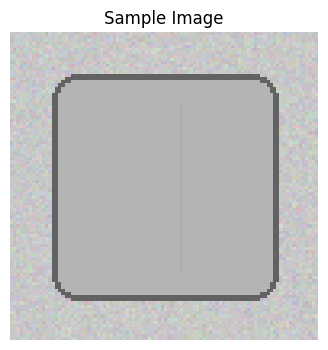

In [43]:
# =========================================================
# IMAGE DIMENSIONS CHECK
# =========================================================

sample_image = Image.open(
    "data/" + labels_df.iloc[0]["filename"]
)

print("Image Size:", sample_image.size)

plt.figure(figsize=(4,4))

plt.imshow(sample_image, cmap="gray")

plt.title("Sample Image")

plt.axis("off")

plt.show()

# Image Preprocessing

Before training the CNN model, the images must be preprocessed.

The preprocessing steps include:
- Reading image files
- Resizing images to fixed dimensions
- Normalizing pixel values
- Converting labels into numerical format
- Splitting data into training and testing sets

Image preprocessing helps improve model performance and training stability.

In [44]:
# =========================================================
# IMAGE PREPROCESSING
# =========================================================

images = []
labels = []

# Automatically create label mapping

unique_classes = labels_df["class"].unique()

label_map = {
    label: index
    for index, label in enumerate(unique_classes)
}

print(label_map)

# Load images
for index, row in labels_df.iterrows():

    image_path = "data/" + row["filename"]

    img = Image.open(image_path)

    # Convert to grayscale
    img = img.convert("L")

    # Resize image
    img = img.resize((96, 96))

    # Convert to numpy array
    img_array = np.array(img)

    # Normalize
    img_array = img_array / 255.0

    images.append(img_array)

    labels.append(label_map[row["class"]])

# Convert to numpy arrays
X = np.array(images)

y = np.array(labels)

# Reshape for CNN
X = X.reshape(-1, 96, 96, 1)

print("Image Data Shape:", X.shape)

print("Labels Shape:", y.shape)

{'normal': 0, 'scratch': 1, 'dent': 2, 'stain': 3}
Image Data Shape: (480, 96, 96, 1)
Labels Shape: (480,)


# Train-Test Split

The dataset is divided into:
- Training set
- Testing set

The training set is used for learning patterns, while the testing set evaluates model performance on unseen data.

In [45]:
# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)

print("Testing Data Shape:", X_test.shape)

Training Data Shape: (384, 96, 96, 1)
Testing Data Shape: (96, 96, 96, 1)


# CNN Model Building

A Convolutional Neural Network (CNN) is created for image classification.

The architecture includes:
- Convolution layers
- ReLU activation
- Max pooling layers
- Flatten layer
- Dense layers
- Output layer

CNNs are highly effective for image-based tasks because they automatically learn visual patterns and features.

In [46]:
# =========================================================
# CNN MODEL BUILDING
# =========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

# Build CNN Model
model = Sequential([

    # First Convolution Layer
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(96,96,1)
    ),

    MaxPooling2D((2,2)),

    # Second Convolution Layer
    Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    MaxPooling2D((2,2)),

    # Flatten Layer
    Flatten(),

    # Dense Layer
    Dense(
        128,
        activation='relu'
    ),

    # Dropout Layer
    Dropout(0.3),

    # Output Layer for 4 Classes
    Dense(
        4,
        activation='softmax'
    )

])

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Show Model Summary
model.summary()

c:\Users\shivi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 94, 94, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,984,388 (15.20 MB)

 Trainable params: 3,984,388 (15.20 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 130ms/step - accuracy: 0.2578 - loss: 1.8078 - val_accuracy: 0.2500 - val_loss: 1.3807
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step - accuracy: 0.3516 - loss: 1.3783 - val_accuracy: 0.3021 - val_loss: 1.3647
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.3750 - loss: 1.3193 - val_accuracy: 0.3854 - val_loss: 1.2299
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5208 - loss: 1.1416 - val_accuracy: 0.5625 - val_loss: 1.0376
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6615 - loss: 0.9488 - val_accuracy: 0.6562 - val_loss: 0.7999
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 124ms/step - accuracy: 0.7083 - loss: 0.7706 - val_accuracy: 0.7396 - val_loss: 0.6633
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.7578 - loss: 0.6811 - val_accuracy: 0.8333 - val_loss: 0.5834
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.7995 - loss: 0.5789 - val_accuracy: 0.

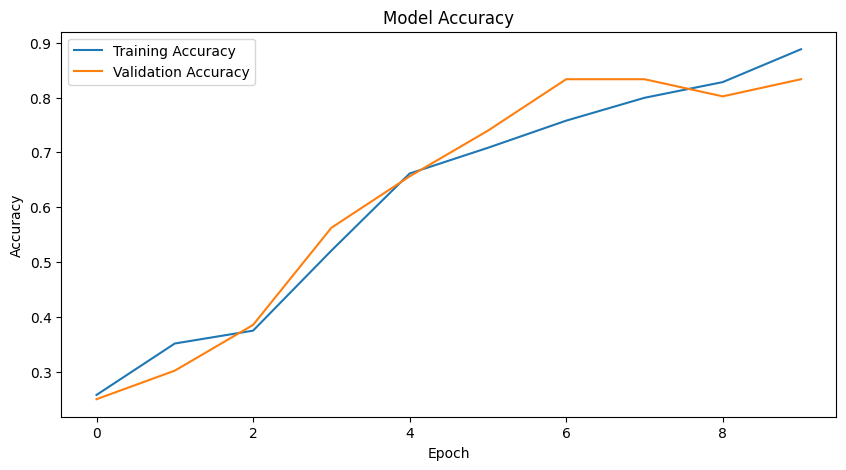

In [48]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig('results/accuracy_loss_curves.png')

plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


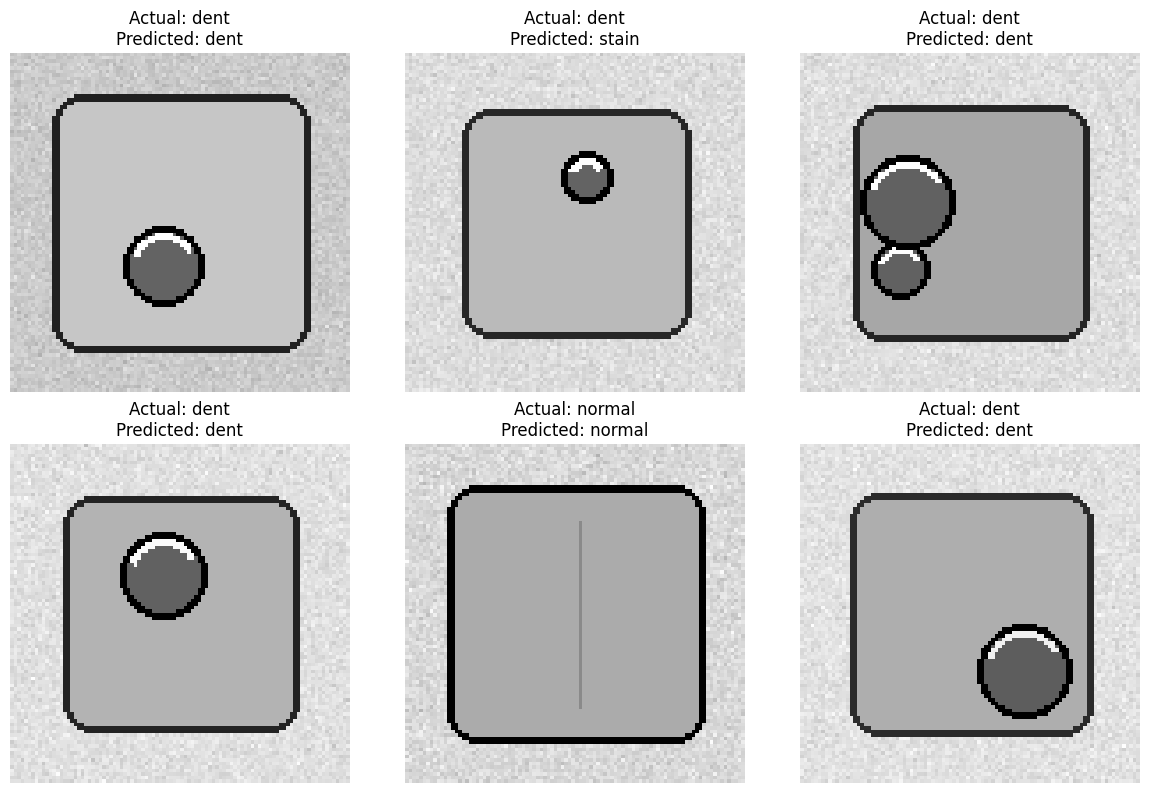

In [51]:
# =========================================================
# SAMPLE PREDICTIONS
# =========================================================

class_names = ['normal', 'scratch', 'dent', 'stain']

# Predict on test data
predictions = model.predict(X_test)

# Convert predictions
predicted_classes = np.argmax(predictions, axis=1)

# Plot sample predictions
plt.figure(figsize=(12,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i].reshape(96,96), cmap='gray')

    plt.title(
        f"Actual: {class_names[y_test[i]]}\nPredicted: {class_names[predicted_classes[i]]}"
    )

    plt.axis('off')

plt.tight_layout()

plt.savefig('sample_predictions/prediction_outputs.png')

plt.show()